In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

In [2]:
df_vendas = pd.read_parquet("../processed/df_Vendas.parquet")

In [3]:
df_vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 1145961 entries, 0 to 1145960
Data columns (total 20 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   Data Venda          1145961 non-null  datetime64[us]
 1   Id Loja             1145961 non-null  int64         
 2   Id Produto          1145961 non-null  int64         
 3   Id Cliente          1145961 non-null  int64         
 4   Qtd. Vendida        1145961 non-null  int64         
 5   Qtd. Devolvida      1145961 non-null  int64         
 6   Preço Unitário      1145961 non-null  float64       
 7   Nome Completo       1145961 non-null  str           
 8   Gênero              1145961 non-null  str           
 9   Data de Nascimento  1145961 non-null  datetime64[us]
 10  Nome Cliente        1145961 non-null  str           
 11  Localidade          1145961 non-null  str           
 12  Cidade              1145961 non-null  str           
 13  Tipo Loja           114

In [4]:
df_vendas["Id Cliente"].nunique()

18484

In [5]:
df_vendas["Id Produto"].nunique()

591

In [6]:
df_vendas["Id Loja"].nunique()

517

In [7]:
df_vendas["Data Venda"].min()

Timestamp('2022-01-01 00:00:00')

In [8]:
df_vendas["Data Venda"].max()

Timestamp('2024-12-30 00:00:00')

In [9]:
df_vendas = df_vendas.drop(columns={
    "Id Cliente",
    "Id Loja",
    "Id Produto"}
)

In [10]:
df_vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 1145961 entries, 0 to 1145960
Data columns (total 17 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   Data Venda          1145961 non-null  datetime64[us]
 1   Qtd. Vendida        1145961 non-null  int64         
 2   Qtd. Devolvida      1145961 non-null  int64         
 3   Preço Unitário      1145961 non-null  float64       
 4   Nome Completo       1145961 non-null  str           
 5   Gênero              1145961 non-null  str           
 6   Data de Nascimento  1145961 non-null  datetime64[us]
 7   Nome Cliente        1145961 non-null  str           
 8   Localidade          1145961 non-null  str           
 9   Cidade              1145961 non-null  str           
 10  Tipo Loja           1145961 non-null  str           
 11  Nome Gerente        1145961 non-null  str           
 12  Sobrenome Gerente   1145961 non-null  str           
 13  Nome Produto        114

In [11]:
df_vendas["Ano Venda"] = df_vendas["Data Venda"].dt.year
df_vendas["Mes Venda"] = df_vendas["Data Venda"].dt.month
df_vendas["Dia Semana Venda"] = df_vendas["Data Venda"].dt.day_name()

In [12]:
df_vendas["Receita"]=(
    (df_vendas["Qtd. Vendida"]-
     df_vendas["Qtd. Devolvida"])*
    (df_vendas["Preço Unitário"]-
     df_vendas["Custo Unitário"])
)

In [13]:
df_vendas["Receita"].sum()

np.float64(317054377.21999997)

In [14]:
df_vendas["Continente"] = (
        df_vendas["Localidade"]
        .str.split(" - ", expand=True)
        .apply(lambda x: f"{x[1]}", axis=1)
    )
df_vendas["País"] = (
        df_vendas["Localidade"]
        .str.split(" - ", expand=True)
        .apply(lambda x: f"{x[0]}", axis=1)
    )

---
### **Receita por Ano**

In [15]:
receita_ano = df_vendas.groupby("Ano Venda")["Receita"].sum()
receita_ano


Ano Venda
2022    3.934781e+07
2023    1.420575e+08
2024    1.356491e+08
Name: Receita, dtype: float64

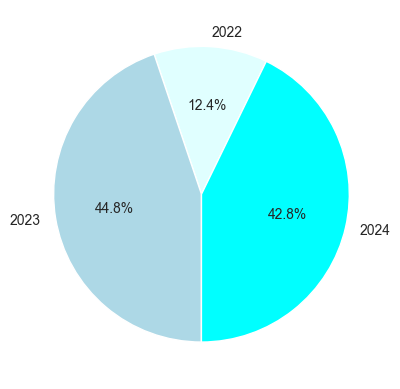

In [16]:
anos = [2022, 2023, 2024]

plt.pie(x=receita_ano.array, labels=anos,autopct='%1.1f%%',startangle=64, colors=["lightcyan","lightblue","cyan"])

plt.show()

---
### **Receita por Mês (sazonalidade)**

Text(0.5, 0, 'Mês')

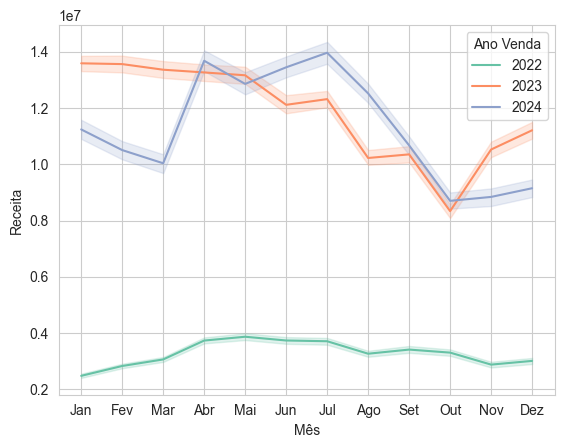

In [17]:
sns.lineplot(data=df_vendas, x= "Mes Venda", y="Receita", hue="Ano Venda" ,estimator="sum", palette="Set2")
ax = plt.gca()
ax.set_xticks([1,2,3,4,5,6,7,8,9,10,11,12])
ax.set_xticklabels(["Jan", "Fev", "Mar","Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"])
plt.xlabel('Mês')

---
### **Produtos mais vendidos**

In [18]:
df_vendas["Qtd. Vendida"].sum()

np.int64(2117268)

In [19]:
quantidade_produtos = df_vendas.groupby("Nome Produto", as_index=False)["Qtd. Vendida"].sum()
top10_quantidade = quantidade_produtos.nlargest(10,"Qtd. Vendida")
top10_quantidade

,Nome Produto,Qtd. Vendida
435,SV 16xDVD M360 Black,240303
34,Camera Lens X400 Silver,99468
146,Contoso USB Cable M250 White,43163
332,MGS Hand Games for Office worker L299 Black,28442
477,SV Hand Games women M40 Black,27191
478,SV Hand Games women M40 Red,26511
348,MGS Hand Games women M400 Black,25194
351,MGS Hand Games women M400 Yellow,25158
335,MGS Hand Games for Office worker L299 Yellow,25042
350,MGS Hand Games women M400 Silver,24908


---
### **Produtos com Maior Receita**

In [20]:
receita_produtos = df_vendas.groupby("Nome Produto", as_index=False)["Receita"].sum()
top10_receita = receita_produtos.nlargest(10,"Receita")
top10_receita

,Nome Produto,Receita
34,Camera Lens X400 Silver,39573542.76
435,SV 16xDVD M360 Black,16469750.76
326,MGS Halo: Combat Evolved E109,10329272.08
577,Washer & Dryer L2700 Green,8147706.42
182,Home Theater Silver,7993373.64
580,Water Purifier Silver,7819527.52
578,Washer & Dryer L2700 Silver,7152526.08
159,Cooktop Inox,3362265.28
557,Washer & Dryer 24in M2400 Green,3300049.55
253,Litware Washer & Dryer 24in M260 White,3220861.60


---
### **Interseção Quantidade $\cap$ Receita**

In [21]:
intersecao = top10_quantidade.merge(
    top10_receita,
    on="Nome Produto",
    how="inner"
)
print(intersecao)

              Nome Produto  Qtd. Vendida      Receita
0     SV 16xDVD M360 Black        240303  16469750.76
1  Camera Lens X400 Silver         99468  39573542.76


Os Dois Produtos mais vendidos são, também, os dois produtos com maior receita

---
### **Clientes que mais geram receita**

In [22]:
receita_clientes = df_vendas.groupby("Nome Cliente", as_index=False)["Receita"].sum()
top10_receita_clientes = receita_clientes.nlargest(10,"Receita")
top10_receita_clientes


,Nome Cliente,Receita
3913,Kyssilla,244775.24
3256,Janitecia,198020.16
5184,Odacio,192445.99
3853,Ketlim,190691.04
6521,Umberto,176127.85
6934,Ygor,174478.99
6352,Thauan,169173.35
5732,Rosemere,166263.67
2944,Ibira,165687.21
5571,Reyner,163864.39


---
### **Clientes que Compram Mais Produtos**

In [23]:
top10_quantidade_clientes = df_vendas.groupby("Nome Cliente", as_index=False)["Qtd. Vendida"].sum().nlargest(10,"Qtd. Vendida")
top10_quantidade_clientes

,Nome Cliente,Qtd. Vendida
3913,Kyssilla,1492
6283,Telson,1287
1331,Danyele,1251
5083,Nicio,1237
4164,Lionel,1201
2362,Gelson,1198
3862,Keyla,1196
1799,Elcio,1182
5184,Odacio,1108
1301,Dan,1105


---
### **Interseção Clientes que Geram Mais Receita $\cap$ Clientes que Mais Compram**

In [24]:
intersecao_clientes = top10_receita_clientes.merge(
    top10_quantidade_clientes,
    on="Nome Cliente",
    how = "inner"
)
print(intersecao_clientes)

  Nome Cliente    Receita  Qtd. Vendida
0     Kyssilla  244775.24          1492
1       Odacio  192445.99          1108


3 dos 10 clientes que mais compram estão entre os 10 que mais geram receita

---

In [25]:
top10_quantidade_gerente = df_vendas.groupby("Nome Gerente", as_index=False)["Qtd. Vendida"].sum().nlargest(10,"Qtd. Vendida")
top10_quantidade_gerente

,Nome Gerente,Qtd. Vendida
0,Ana,159949
12,Luiz,141810
1,Beatriz,135958
13,Marcos,135745
11,Lucas,127787
5,Gabriel,114383
15,Paulo,113137
10,Lara,111311
8,João,111123
14,Maria,110804


In [26]:
top10_receita_gerente = df_vendas.groupby("Nome Gerente", as_index=False)["Receita"].sum().nlargest(10,"Receita")
top10_receita_gerente

,Nome Gerente,Receita
0,Ana,23897564.23
12,Luiz,21406219.83
1,Beatriz,20555309.02
13,Marcos,20261037.43
11,Lucas,18915849.90
5,Gabriel,17296781.28
15,Paulo,17065953.51
14,Maria,16704930.58
16,Pedro,16583824.42
10,Lara,16542625.03


In [27]:
df_vendas.loc[df_vendas["Nome Gerente"]=='João'].groupby("Nome Gerente")["Receita"].sum()

Nome Gerente
João    16533907.76
Name: Receita, dtype: float64

In [28]:
df_vendas.iloc[df_vendas["Nome Gerente"]=='Pedro'].groupby("Nome Gerente")["Qtd. Vendida"].sum()

Nome Gerente
Pedro    110377
Name: Qtd. Vendida, dtype: int64

In [29]:
intersecao_gerente = top10_quantidade_gerente.merge(
    top10_receita_gerente,
    on="Nome Gerente",
    how="inner"
)
print(intersecao_gerente)

  Nome Gerente  Qtd. Vendida      Receita
0          Ana        159949  23897564.23
1         Luiz        141810  21406219.83
2      Beatriz        135958  20555309.02
3       Marcos        135745  20261037.43
4        Lucas        127787  18915849.90
5      Gabriel        114383  17296781.28
6        Paulo        113137  17065953.51
7         Lara        111311  16542625.03
8        Maria        110804  16704930.58


---
### **Produtos Mais Devolvidos**

In [30]:
top10_quantidade_produtos_devolvidos = df_vendas.groupby("Nome Produto", as_index=False)["Qtd. Devolvida"].sum().nlargest(10,"Qtd. Devolvida")
top10_quantidade_produtos_devolvidos

,Nome Produto,Qtd. Devolvida
477,SV Hand Games women M40 Black,48
350,MGS Hand Games women M400 Silver,47
278,MGS Age of Empires III: The War Chiefs M240,46
332,MGS Hand Games for Office worker L299 Black,46
325,MGS Halo 2 for Windows Vista M220,45
275,MGS Age of Empires III: The Asian Dynasties M180,44
283,MGS Age of Mythology: Gold Edition M310,42
396,MGS Zoo Tycoon 2: Zookeeper Collection M260,42
290,MGS Bicycle Casino Games X700,41
383,MGS Shadow-run M230,41


In [31]:
df_devolucao = top10_quantidade_produtos_devolvidos.merge(
    df_vendas.groupby("Nome Produto", as_index=False)
      .agg({
          "Qtd. Vendida": "sum",
          "Preço Unitário": "first",
          "Custo Unitário": "first",
          "Receita": "sum"
      }),
    on= "Nome Produto"
)
df_devolucao["Receita Negada"] = df_devolucao["Qtd. Devolvida"] *(df_devolucao["Preço Unitário"]-df_devolucao["Custo Unitário"])
df_devolucao.nlargest(10, "Receita Negada")

,Nome Produto,Qtd. Devolvida,Qtd. Vendida,Preço Unitário,Custo Unitário,Receita,Receita Negada
8,MGS Bicycle Casino Games X700,41,4939,109.00,36.11,357015.22,2988.49
6,MGS Age of Mythology: Gold Edition M310,42,6402,79.80,36.70,274116.00,1810.20
2,MGS Age of Empires III: The War Chiefs M240,46,6231,70.13,32.25,234287.80,1742.48
4,MGS Halo 2 for Windows Vista M220,45,5437,70.13,32.25,204248.96,1704.60
5,MGS Age of Empires III: The Asian Dynasties M180,44,6434,70.13,32.25,242053.20,1666.72
7,MGS Zoo Tycoon 2: Zookeeper Collection M260,42,6823,70.13,32.25,256864.28,1590.96
9,MGS Shadow-run M230,41,5981,70.13,32.25,225007.20,1553.08
3,MGS Hand Games for Office worker L299 Black,46,28442,16.89,5.60,320590.84,519.34
0,SV Hand Games women M40 Black,48,27191,8.88,4.08,130286.40,230.40
1,MGS Hand Games women M400 Silver,47,24908,8.99,4.13,120824.46,228.42


---

In [32]:
df_vendas.groupby("Localidade", as_index=False)["Qtd. Vendida"].sum().nlargest(10,"Qtd. Vendida")

,Localidade,Qtd. Vendida
10,Estados Unidos - América do Norte,1153934
15,Inglaterra - Europa,181278
0,Alemanha - Europa,171759
11,França - Europa,167810
2,Austrália - Austrália,163339
4,Canada - América do Norte,85737
19,Japão - Ásia,28517
18,Itália - Europa,20712
5,China - Ásia,20554
26,Russia - Europa,12491


In [33]:
df_vendas.groupby("Localidade", as_index=False)["Receita"].sum().nlargest(10,"Receita")

,Localidade,Receita
10,Estados Unidos - América do Norte,1.734101e+08
15,Inglaterra - Europa,2.724649e+07
0,Alemanha - Europa,2.539700e+07
2,Austrália - Austrália,2.480884e+07
11,França - Europa,2.478661e+07
4,Canada - América do Norte,1.277005e+07
19,Japão - Ásia,4.307141e+06
5,China - Ásia,3.175069e+06
18,Itália - Europa,3.059420e+06
14,India - Ásia,1.848788e+06


In [34]:
df_vendas.groupby("Cidade", as_index=False)["Qtd. Vendida"].sum().nlargest(10,"Qtd. Vendida")

,Cidade,Qtd. Vendida
407,Saint Ouen,12415
129,Columbus,8379
176,Frankfurt,8320
46,Birmingham,8316
70,Burbank,8266
58,Bracknell,4508
504,Woodland Hills,4411
0,Albany,4403
104,Chatou,4393
264,Ljubljana,4391


In [35]:
df_vendas.groupby("Cidade", as_index=False)["Receita"].sum().nlargest(10,"Receita")

,Cidade,Receita
407,Saint Ouen,1832487.75
129,Columbus,1326379.40
176,Frankfurt,1283064.41
46,Birmingham,1242506.93
70,Burbank,1218777.37
58,Bracknell,741784.28
261,Litchfield County,723180.70
426,Shanghai,717906.01
364,Pasadena,713014.37
213,Holyoke,701907.72


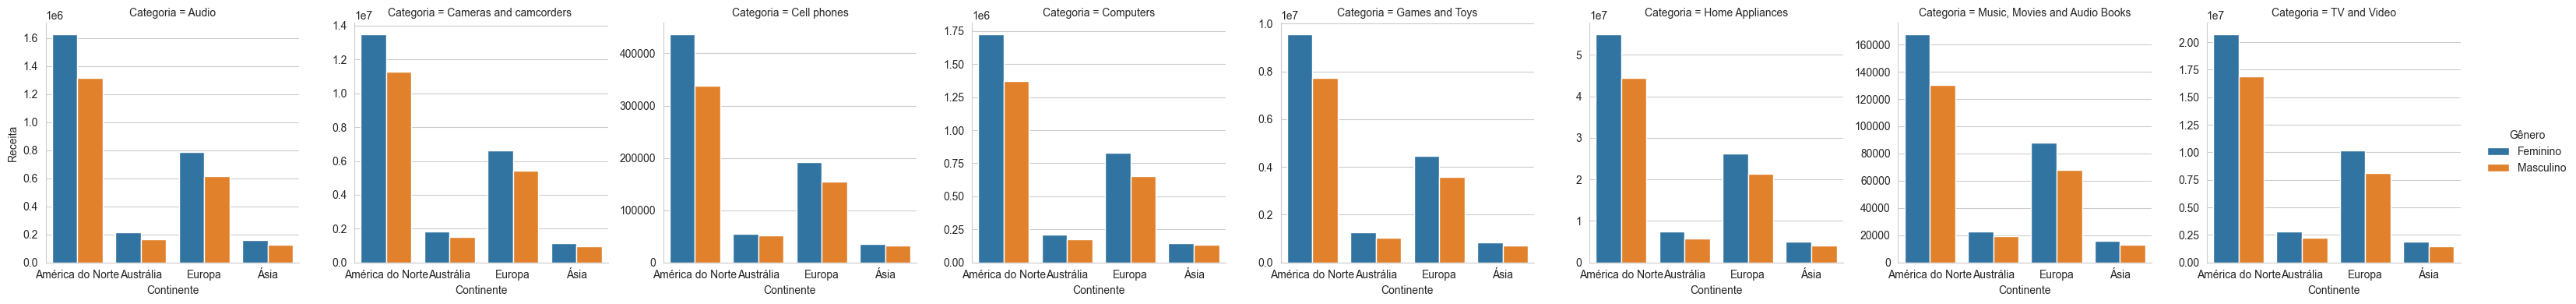

In [45]:
sns.catplot(
    data=df_vendas.groupby(["Continente", "Gênero","Categoria"], as_index=False)["Receita"].sum(),
    kind="bar",
    x="Continente",
    y="Receita",
    hue="Gênero",
    col="Categoria",
    height=4,
    sharey=False
)

In [47]:
df_vendas.groupby("Marca", as_index=False)["Receita"].sum().nlargest(10,"Receita")

,Marca,Receita
2,Contoso,1.240359e+08
8,Northwind Traders,6.689655e+07
6,Litware,4.172757e+07
11,Tailspin Toys,2.762844e+07
10,Southridge Video,2.056760e+07
7,Litware,1.576886e+07
1,Adventure Works,5.108910e+06
4,Fabrikam,4.460511e+06
13,Wide World Importers,3.380038e+06
3,Contoso,2.883548e+06


In [ ]:
df_vendas.groupby("Marca", as_index=False)["Qtd. Vendida"].sum().nlargest(10,"Qtd. Vendida")

,Marca,Qtd. Vendida
11,Tailspin Toys,886782
10,Southridge Video,598563
2,Contoso,361084
8,Northwind Traders,71114
6,Litware,65068
7,Litware,56457
13,Wide World Importers,29873
1,Adventure Works,11592
3,Contoso,9746
12,The Phone Company,8594


In [38]:
df_vendas.columns

Index(['Data Venda', 'Qtd. Vendida', 'Qtd. Devolvida', 'Preço Unitário',
       'Nome Completo', 'Gênero', 'Data de Nascimento', 'Nome Cliente',
       'Localidade', 'Cidade', 'Tipo Loja', 'Nome Gerente',
       'Sobrenome Gerente', 'Nome Produto', 'Categoria', 'Marca',
       'Custo Unitário', 'Ano Venda', 'Mes Venda', 'Dia Semana Venda',
       'Receita', 'Continente', 'País'],
      dtype='str')